In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV
df = pd.read_csv("pakistan_road_accidents.csv")

# Basic Info
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (55000, 20)

Missing Values:
 year                  0
month                 0
day_of_week           0
hour_of_day           0
province              0
district              0
road_type             0
road_condition        0
weather_condition     0
lighting_condition    0
vehicle_type          0
vehicles_involved     0
accident_cause        0
is_rush_hour          0
is_weekend            0
is_night              0
is_foggy_month        0
num_injured           0
num_killed            0
severity              0
dtype: int64

Duplicates: 0


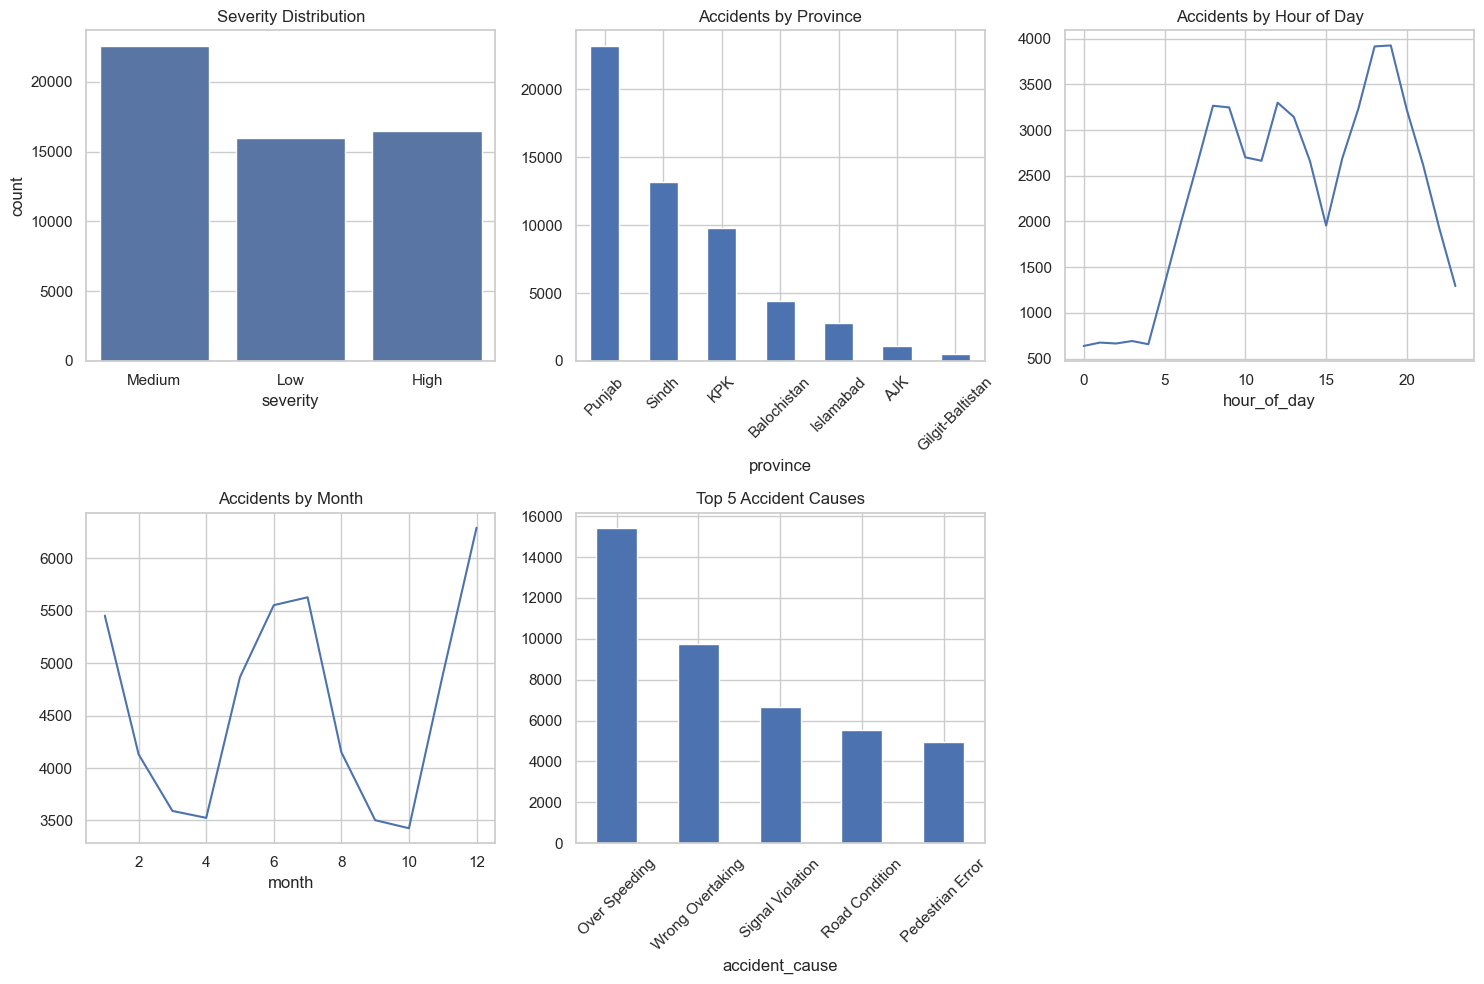

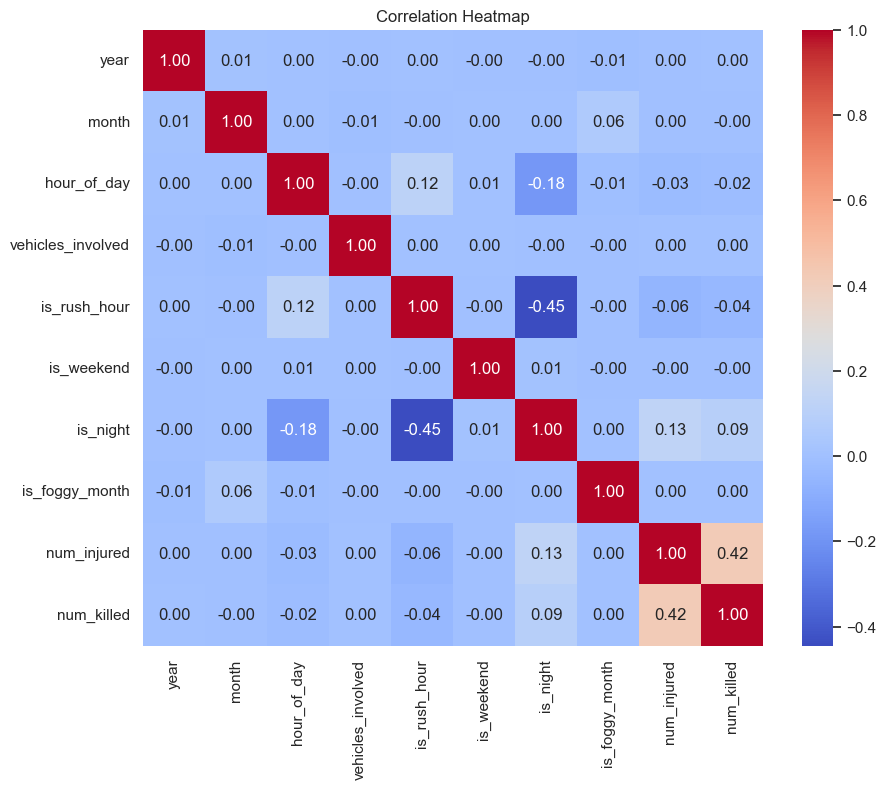

In [2]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# 1. Severity Distribution
plt.subplot(2, 3, 1)
sns.countplot(x='severity', data=df)
plt.title('Severity Distribution')

# 2. Accidents by Province
plt.subplot(2, 3, 2)
df['province'].value_counts().plot(kind='bar')
plt.title('Accidents by Province')
plt.xticks(rotation=45)

# 3. Accidents by Hour of Day
plt.subplot(2, 3, 3)
df.groupby('hour_of_day').size().plot(kind='line')
plt.title('Accidents by Hour of Day')

# 4. Accidents by Month
plt.subplot(2, 3, 4)
df.groupby('month').size().plot(kind='line')
plt.title('Accidents by Month')

# 5. Top 5 Accident Causes
plt.subplot(2, 3, 5)
df['accident_cause'].value_counts().head().plot(kind='bar')
plt.title('Top 5 Accident Causes')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 6. Heatmap of Correlation
numeric_cols = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical columns (excluding target 'severity' for now)
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns

# Exclude severity if it's there
if 'severity' in cat_cols:
    cat_cols = cat_cols.drop('severity')

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Separate X and y
X = df.drop('severity', axis=1)

# Encode 'severity': Low=0, Medium=1, High=2
severity_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = df['severity'].map(severity_map)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (44000, 19)
X_test shape: (11000, 19)
y_train shape: (44000,)
y_test shape: (11000,)


C:\Users\PMLS\AppData\Local\Temp\ipykernel_15888\806402099.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [4]:
from sklearn.preprocessing import StandardScaler

# Define numeric columns for scaling
num_cols = ['vehicles_involved', 'num_injured', 'num_killed', 'hour_of_day', 'month', 'year']

scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Sample scaled features (X_train):")
print(X_train[num_cols].head())

Sample scaled features (X_train):
       vehicles_involved  num_injured  num_killed  hour_of_day     month  \
24725          -1.171847     0.546712    0.400260     0.456507 -0.173216   
65             -0.023975    -0.159137    1.500083    -0.243858  0.955643   
52496          -0.023975     1.252560    2.599906     1.507054  0.108999   
36590          -0.023975    -0.159137    0.400260     0.806689  1.237858   
24397          -0.023975     0.546712   -0.699562     0.806689 -0.173216   

           year  
24725  0.662591  
65    -1.696434  
52496  0.072835  
36590  0.072835  
24397 -1.696434  


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("STEP 1: BASELINE MODEL (Logistic Regression)\n")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_preds)
print("Logistic Regression Accuracy:", lr_accuracy)
print("\nClassification Report:\n", classification_report(y_test, lr_preds))

STEP 1: BASELINE MODEL (Logistic Regression)

Logistic Regression Accuracy: 0.7745454545454545

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80      3235
           1       0.72      0.75      0.73      4521
           2       0.84      0.78      0.81      3244

    accuracy                           0.77     11000
   macro avg       0.79      0.78      0.78     11000
weighted avg       0.78      0.77      0.78     11000



STEP 2: RANDOM FOREST

Random Forest Accuracy: 0.8719090909090909

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89      3235
           1       0.82      0.88      0.85      4521
           2       0.95      0.83      0.89      3244

    accuracy                           0.87     11000
   macro avg       0.88      0.87      0.88     11000
weighted avg       0.88      0.87      0.87     11000



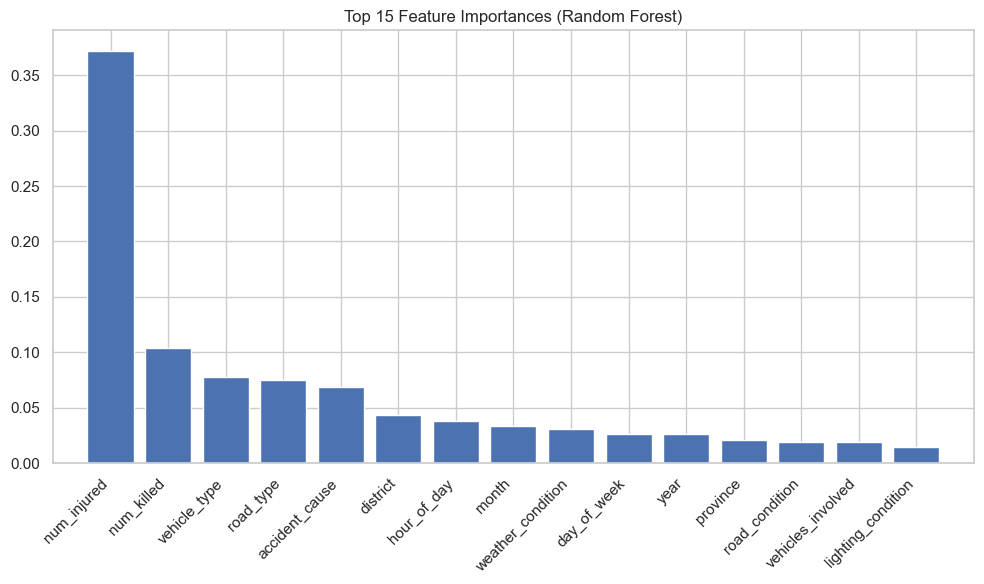

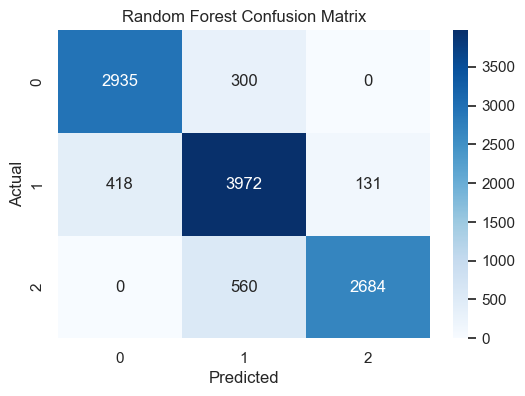

In [6]:
from sklearn.ensemble import RandomForestClassifier

print("STEP 2: RANDOM FOREST\n")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10, 6))
plt.title("Top 15 Feature Importances (Random Forest)")
plt.bar(range(15), importances[indices][:15], align="center")
plt.xticks(range(15), [features[i] for i in indices[:15]], rotation=45, ha='right')
plt.xlim([-1, 15])
plt.tight_layout()
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

STEP 3: XGBOOST



c:\Users\PMLS\Desktop\data_science_project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:20:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.881

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89      3235
           1       0.84      0.87      0.86      4521
           2       0.94      0.87      0.90      3244

    accuracy                           0.88     11000
   macro avg       0.89      0.88      0.88     11000
weighted avg       0.88      0.88      0.88     11000



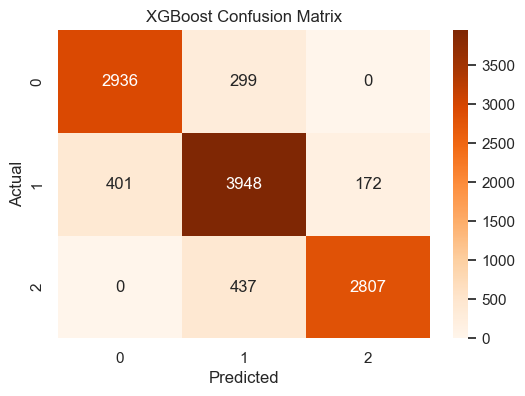

In [7]:
import xgboost as xgb

print("STEP 3: XGBOOST\n")
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_preds)

print("XGBoost Accuracy:", xgb_accuracy)
print("\nClassification Report:\n", classification_report(y_test, xgb_preds))

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

STEP 4: MODEL COMPARISON

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.774545   0.777104  0.774545  0.775309
1        Random Forest  0.871909   0.876463  0.871909  0.872399
2              XGBoost  0.881000   0.883052  0.881000  0.881369


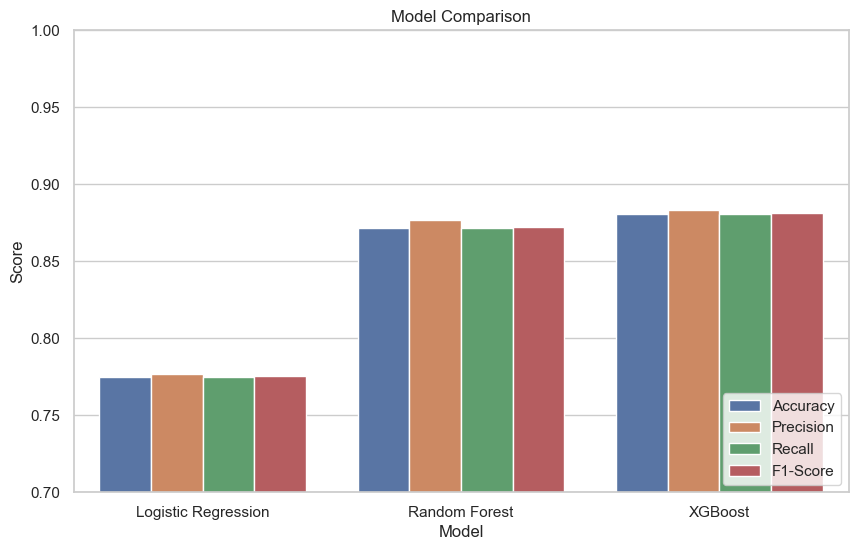

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("STEP 4: MODEL COMPARISON\n")

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
preds = [lr_preds, rf_preds, xgb_preds]

results = []
for model_name, p in zip(models, preds):
    acc = accuracy_score(y_test, p)
    prec = precision_score(y_test, p, average='weighted')
    rec = recall_score(y_test, p, average='weighted')
    f1 = f1_score(y_test, p, average='weighted')
    results.append([model_name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print(results_df)

# Grouped bar chart
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted)
plt.title('Model Comparison')
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.show()

c:\Users\PMLS\Desktop\data_science_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


STEP 5: SHAP EXPLAINABILITY

SHAP Summary Plot (Beeswarm) for Class 2 (High Severity):


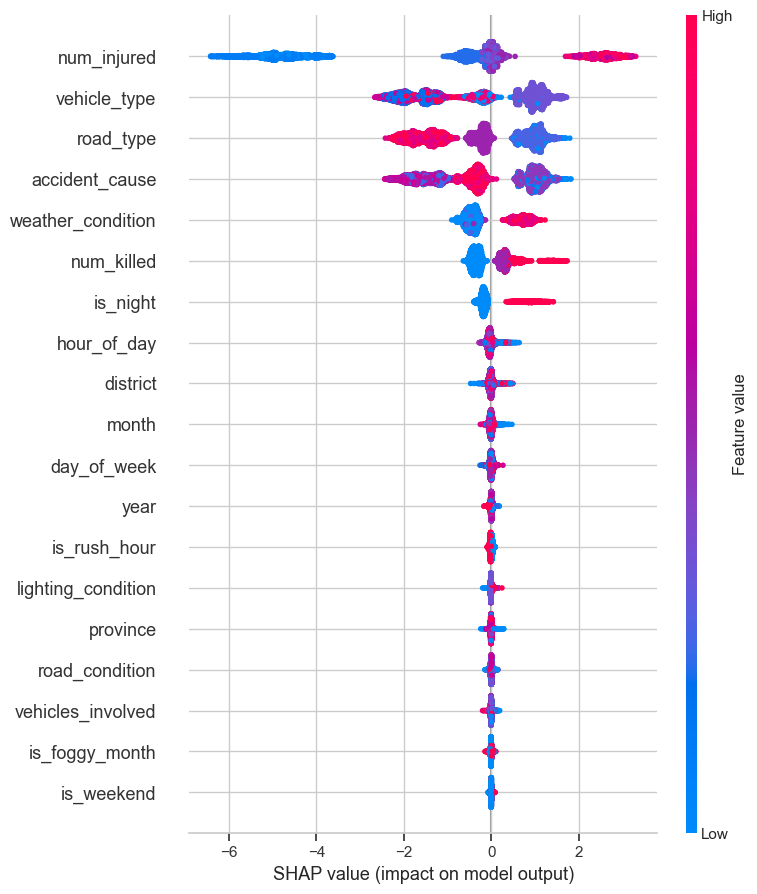

SHAP Bar Plot (Mean Importance):


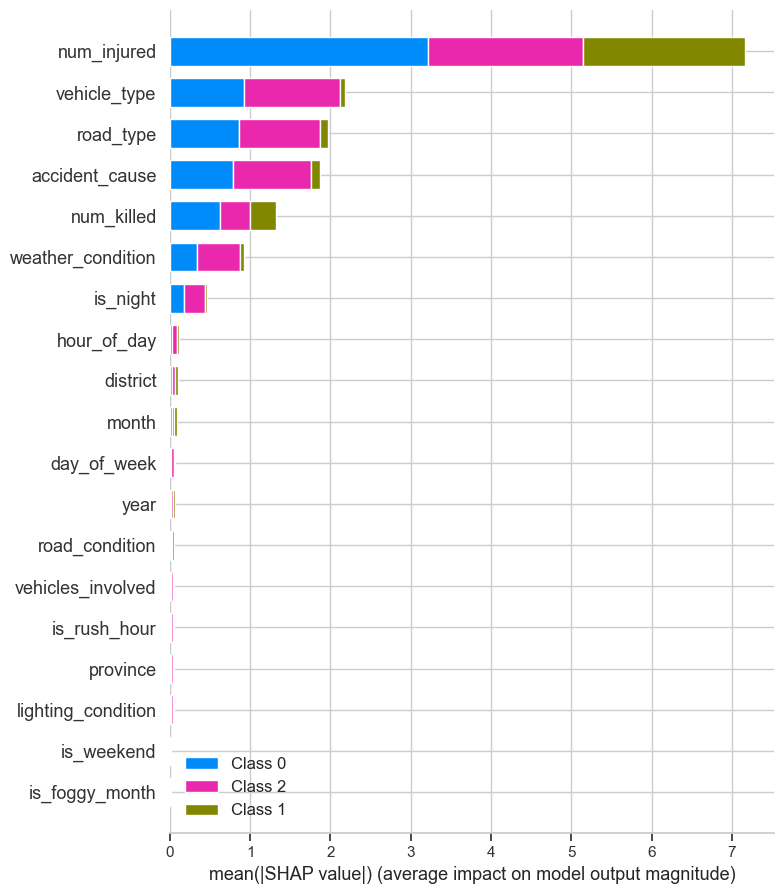


Top 5 Most Important Features (SHAP):
           Feature  Importance
17     num_injured    2.389026
10    vehicle_type    0.726261
6        road_type    0.656833
12  accident_cause    0.623069
18      num_killed    0.439639

Saving best model and scaler...
Saved accident_severity_model.pkl and scaler.pkl successfully.


In [9]:
import shap
import joblib

print("STEP 5: SHAP EXPLAINABILITY\n")

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)
# Calculate SHAP values for a subset of X_test to save time (or all if feasible, 11000 is okay but let's do all)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary plot (beeswarm)
# Since it's a multi-class problem, shap_values is a list of arrays (one for each class)
# We can plot for class 2 (High Severity) or use a summary bar plot for all classes
print("SHAP Summary Plot (Beeswarm) for Class 2 (High Severity):")
shap.summary_plot(shap_values[:, :, 2] if len(np.shape(shap_values)) == 3 else shap_values[2], X_test)

print("SHAP Bar Plot (Mean Importance):")
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Top 5 most important features according to SHAP (using mean absolute SHAP value across all classes)
# shap_values shape: (n_samples, n_features, n_classes) or list of (n_samples, n_features)
if isinstance(shap_values, list):
    mean_shap = np.abs(shap_values).mean(axis=(0, 1))
else:
    mean_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': mean_shap
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Most Important Features (SHAP):")
print(shap_importance.head())

# Save the best model (XGBoost based on accuracy) and the scaler
print("\nSaving best model and scaler...")
joblib.dump(xgb_model, 'accident_severity_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Saved accident_severity_model.pkl and scaler.pkl successfully.")